# 02 - Weather Data Integration

## Objective
Fetch historical + forward weather data for the 5 active Club Piscine store cities.


## Data Sources
- **Open-Meteo Archive API** — historical daily weather (free, no key)
- **Open-Meteo Forecast API** — up to 16 days ahead (free, no key)
- **python-holidays** — Quebec + Ontario statutory holidays

## Input
- `data/processed/weekly_units.csv`

## Output
- `data/processed/weather_by_city_week.csv`
- `data/processed/weekly_units_weather.csv`
---

---
## Cell 1: Imports and Setup
---

In [15]:
import pandas as pd
import numpy as np
import requests
import holidays as holidays_lib
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
sns.set_palette('husl')

PROJECT_ROOT   = Path('..')
DATA_PROCESSED = PROJECT_ROOT / 'data' / 'processed'
FIGURES        = PROJECT_ROOT / 'reports' / 'figures'
print('✅ Imports complete')

✅ Imports complete


---
## Cell 2: City Configuration
---

In [16]:
weekly = pd.read_csv(DATA_PROCESSED / 'weekly_units.csv')
weekly['week_ending'] = pd.to_datetime(weekly['week_ending'])
print(f'weekly_units loaded: {weekly.shape}  (stores: {weekly["store_code"].nunique()}, divs: {weekly["division_code"].nunique()})')

# ── City coordinates for all 20 active stores ─────────────────────────────────
# Stores excluded: CP01,CP05,CP11,CP12,CP18,CP20,CP29,CP40,CP43,CP47
CITY_COORDS = {
    'Blainville':              {'lat': 45.6700, 'lon': -73.8700, 'province': 'QC', 'store': 'CP02'},
    'Drummondville':           {'lat': 45.8833, 'lon': -72.4833, 'province': 'QC', 'store': 'CP04'},
    'Sherbrooke':              {'lat': 45.4042, 'lon': -71.8929, 'province': 'QC', 'store': 'CP05'},
    'Granby':                  {'lat': 45.4000, 'lon': -72.7333, 'province': 'QC', 'store': 'CP06'},
    'Laval':                   {'lat': 45.5833, 'lon': -73.7500, 'province': 'QC', 'store': 'CP07'},
    'Longueuil':               {'lat': 45.5317, 'lon': -73.5180, 'province': 'QC', 'store': 'CP08'},
    'Saint-Jérôme':            {'lat': 45.7833, 'lon': -74.0000, 'province': 'QC', 'store': 'CP10'},
    'St-Georges-de-Beauce':    {'lat': 46.1167, 'lon': -70.6667, 'province': 'QC', 'store': 'CP12'},
    'Victoriaville':           {'lat': 46.0500, 'lon': -71.9667, 'province': 'QC', 'store': 'CP13'},
    'Repentigny':              {'lat': 45.7333, 'lon': -73.4500, 'province': 'QC', 'store': 'CP15'},
    'Chicoutimi':              {'lat': 48.4167, 'lon': -71.0667, 'province': 'QC', 'store': 'CP16'},
    'Trois-Rivières':          {'lat': 46.3500, 'lon': -72.5500, 'province': 'QC', 'store': 'CP17'},
    "Val-d'Or":                {'lat': 48.1000, 'lon': -77.7833, 'province': 'QC', 'store': 'CP18'},
    'Nepean':                  {'lat': 45.3192, 'lon': -75.7166, 'province': 'ON', 'store': 'CP202'},
    'Pointe-aux-Trembles':     {'lat': 45.6667, 'lon': -73.5000, 'province': 'QC', 'store': 'CP28'},
    'St-Hyacinthe':            {'lat': 45.6167, 'lon': -72.9500, 'province': 'QC', 'store': 'CP32'},
    'Sorel-Tracy':             {'lat': 46.0333, 'lon': -73.1167, 'province': 'QC', 'store': 'CP33'},
    'Saint-Jean-sur-Richelieu':{'lat': 45.3000, 'lon': -73.2667, 'province': 'QC', 'store': 'CP35'},
    'Saint-Eustache':          {'lat': 45.5667, 'lon': -73.9000, 'province': 'QC', 'store': 'CP36'},
    'Gatineau':                {'lat': 45.4765, 'lon': -75.7013, 'province': 'QC', 'store': 'CP37'},
    'Joliette':                {'lat': 46.0167, 'lon': -73.4500, 'province': 'QC', 'store': 'CP39'},
    'Thetford Mines':          {'lat': 46.1000, 'lon': -71.3000, 'province': 'QC', 'store': 'CP40'},
    'St-Constant':             {'lat': 45.3688, 'lon': -73.5698, 'province': 'QC', 'store': 'CP44'},
    'Cowansville':             {'lat': 45.2000, 'lon': -72.7500, 'province': 'QC', 'store': 'CP45'},
    'Sainte-Agathe-des-Monts': {'lat': 46.0500, 'lon': -74.2833, 'province': 'QC', 'store': 'CP46'},
    'Riviere-du-Loup':         {'lat': 47.8333, 'lon': -69.5333, 'province': 'QC', 'store': 'CP47'},
    'Beloeil':                 {'lat': 45.5638, 'lon': -73.2052, 'province': 'QC', 'store': 'CP48'},
    # CP77 (Liquidation) shares Laval weather; CP100 shares Saint-Jérôme weather
    # They are handled by the STORE_CITY_MAP below — no separate coord entry needed
}

# Maps every store to its weather city
# CP77 → Laval (same regroupement as CP07)
# CP100 → Saint-Jérôme (same regroupement as CP10)
STORE_CITY_MAP = {
    'CP02':'Blainville',       'CP04':'Drummondville',    'CP05':'Sherbrooke',
    'CP06':'Granby',           'CP07':'Laval',            'CP08':'Longueuil',
    'CP10':'Saint-Jérôme',     'CP12':'St-Georges-de-Beauce', 'CP13':'Victoriaville',
    'CP15':'Repentigny',       'CP16':'Chicoutimi',       'CP17':'Trois-Rivières',
    'CP18':"Val-d'Or",         'CP202':'Nepean',          'CP28':'Pointe-aux-Trembles',
    'CP32':'St-Hyacinthe',     'CP33':'Sorel-Tracy',
    'CP35':'Saint-Jean-sur-Richelieu', 'CP36':'Saint-Eustache',
    'CP37':'Gatineau',         'CP39':'Joliette',         'CP40':'Thetford Mines',
    'CP44':'St-Constant',      'CP45':'Cowansville',
    'CP46':'Sainte-Agathe-des-Monts',  'CP47':'Riviere-du-Loup',
    'CP48':'Beloeil',
    'CP77':'Laval',            'CP100':'Saint-Jérôme',
}
from datetime import date, timedelta

START_DATE = weekly['week_ending'].min().strftime('%Y-%m-%d')

# Archive API only covers up to ~5 days ago — cap END_DATE at yesterday
# Anything more recent comes from the forecast API (Cell 5)
yesterday  = date.today() - timedelta(days=1)
data_end   = weekly['week_ending'].max().date()
END_DATE   = min(data_end, yesterday).strftime('%Y-%m-%d')

FORECAST_DAYS = 16  # forward forecast from today

print(f'Date range      : {START_DATE} → {END_DATE}')
print(f'Forward forecast: {FORECAST_DAYS} days')
print(f'Cities          : {len(CITY_COORDS)}')


weekly_units loaded: (24323, 7)  (stores: 28, divs: 11)
Date range      : 2023-11-05 → 2026-03-19
Forward forecast: 16 days
Cities          : 27


In [17]:
# Validate and standardise weekly schema for merge
print("Columns in weekly_units:")
print(list(weekly.columns))

# weekly_units.csv from nb01 already has store_code, city, division_code, units, revenue
# This cell is a safety net in case any are missing
rename_map = {}
if 'No. magasin' in weekly.columns:
    rename_map['No. magasin'] = 'store_code'
weekly = weekly.rename(columns=rename_map)

# Full store → city mapping for all 22 active stores
STORE_TO_CITY = {
    'CP02':'Blainville',       'CP04':'Drummondville',    'CP05':'Sherbrooke',
    'CP06':'Granby',           'CP07':'Laval',            'CP08':'Longueuil',
    'CP10':'Saint-Jérôme',     'CP12':'St-Georges-de-Beauce', 'CP13':'Victoriaville',
    'CP15':'Repentigny',       'CP16':'Chicoutimi',       'CP17':'Trois-Rivières',
    'CP18':"Val-d'Or",         'CP202':'Nepean',          'CP28':'Pointe-aux-Trembles',
    'CP32':'St-Hyacinthe',     'CP33':'Sorel-Tracy',
    'CP35':'Saint-Jean-sur-Richelieu', 'CP36':'Saint-Eustache',
    'CP37':'Gatineau',         'CP39':'Joliette',         'CP40':'Thetford Mines',
    'CP44':'St-Constant',      'CP45':'Cowansville',
    'CP46':'Sainte-Agathe-des-Monts',  'CP47':'Riviere-du-Loup',
    'CP48':'Beloeil',
    'CP77':'Laval',            'CP100':'Saint-Jérôme',
}

if 'city' not in weekly.columns:
    weekly['city'] = weekly['store_code'].map(STORE_TO_CITY)

missing_city = weekly['city'].isna().sum()
if missing_city:
    print(f"⚠ {missing_city} rows have no city — check STORE_TO_CITY mapping")

print(f"✅ weekly ready: {weekly.shape}")
print(f"   Columns: {list(weekly.columns)}")
weekly[['store_code','city','week_ending']].drop_duplicates().head()


Columns in weekly_units:
['week_ending', 'store_code', 'city', 'division_code', 'units', 'revenue', 'n_transactions']
✅ weekly ready: (24323, 7)
   Columns: ['week_ending', 'store_code', 'city', 'division_code', 'units', 'revenue', 'n_transactions']


,store_code,city,week_ending
0,CP02,Blainville,2023-11-05
5,CP04,Drummondville,2023-11-05
11,CP06,Granby,2023-11-05
16,CP07,Laval,2023-11-05
25,CP08,Longueuil,2023-11-05


---
## Cell 3: Weather Classification (WMO Codes)
---

In [18]:
def classify_weather(df):
    """
    Map WMO weather codes to conditions and binary flags.
    Reference: https://open-meteo.com/en/docs#weathervariables
    """
    def get_condition(code):
        if   code == 0:                return 'Clear'
        elif code in range(1, 4):      return 'Cloudy'
        elif code in range(45, 50):    return 'Fog'
        elif code in range(51, 68):    return 'Rain'
        elif code in range(71, 78):    return 'Snow'
        elif code in range(80, 83):    return 'Rain'
        elif code in range(85, 87):    return 'Snow'
        elif code in range(95, 100):   return 'Thunderstorm'
        else:                           return 'Other'

    df = df.copy()
    df['weather_condition'] = df['weathercode'].apply(get_condition)
    df['is_rain']            = (df['weather_condition'] == 'Rain').astype(int)
    df['is_snow']            = (df['weather_condition'] == 'Snow').astype(int)
    df['is_bad_weather']     = df['weather_condition'].isin(
        ['Rain', 'Snow', 'Thunderstorm', 'Fog']).astype(int)
    return df

print('✅ classify_weather() defined')

✅ classify_weather() defined


---
## Cell 4: Fetch Historical Weather
---

In [19]:
import time

def fetch_historical_weather(city, lat, lon, start_date, end_date, max_retries=4):
    url    = 'https://archive-api.open-meteo.com/v1/archive'
    params = {
        'latitude': lat, 'longitude': lon,
        'start_date': start_date, 'end_date': end_date,
        'daily': ['temperature_2m_mean','temperature_2m_max',
                  'precipitation_sum','weathercode','sunshine_duration'],
        'timezone': 'America/Toronto'
    }
    for attempt in range(max_retries):
        r = requests.get(url, params=params, timeout=30)
        if r.status_code == 429:
            wait = 2 ** (attempt + 2)   # 4s, 8s, 16s, 32s
            print(f'      Rate limited — waiting {wait}s...')
            time.sleep(wait)
            continue
        r.raise_for_status()
        data = r.json()['daily']
        df   = pd.DataFrame({
            'date':           pd.to_datetime(data['time']),
            'temp_mean':      data['temperature_2m_mean'],
            'temp_max':       data['temperature_2m_max'],
            'precipitation':  data['precipitation_sum'],
            'weathercode':    [int(c) for c in data['weathercode']],
            'sunshine_hours': [s/3600 if s else 0 for s in data['sunshine_duration']],
            'city': city
        }).fillna(0)
        return classify_weather(df)
    raise Exception(f'Failed after {max_retries} retries (rate limit)')


all_hist = []
for city, coords in CITY_COORDS.items():
    print(f'  Fetching historical: {city}...')
    try:
        df = fetch_historical_weather(city, coords['lat'], coords['lon'], START_DATE, END_DATE)
        all_hist.append(df)
        print(f'    ✓ {len(df)} days')
    except Exception as e:
        print(f'    ✗ Failed: {e}')
    time.sleep(2)   # 2s pause between every city to stay under rate limit

weather_daily = pd.concat(all_hist, ignore_index=True) if all_hist else pd.DataFrame()
n_cities_ok  = len(all_hist)
n_cities_tot = len(CITY_COORDS)
print(f'\n✅ Historical weather: {weather_daily.shape[0]:,} daily records across {n_cities_ok}/{n_cities_tot} cities')
if n_cities_ok < n_cities_tot:
    fetched = {df['city'].iloc[0] for df in all_hist}
    missing = [c for c in CITY_COORDS if c not in fetched]
    print(f'⚠ Missing cities: {missing} — re-run this cell to retry')


  Fetching historical: Blainville...
    ✓ 866 days
  Fetching historical: Drummondville...
    ✓ 866 days
  Fetching historical: Sherbrooke...
    ✓ 866 days
  Fetching historical: Granby...
    ✓ 866 days
  Fetching historical: Laval...
    ✓ 866 days
  Fetching historical: Longueuil...
    ✓ 866 days
  Fetching historical: Saint-Jérôme...
    ✓ 866 days
  Fetching historical: St-Georges-de-Beauce...
    ✓ 866 days
  Fetching historical: Victoriaville...
    ✓ 866 days
  Fetching historical: Repentigny...
    ✓ 866 days
  Fetching historical: Chicoutimi...
    ✓ 866 days
  Fetching historical: Trois-Rivières...
    ✓ 866 days
  Fetching historical: Val-d'Or...
    ✓ 866 days
  Fetching historical: Nepean...
    ✓ 866 days
  Fetching historical: Pointe-aux-Trembles...
    ✓ 866 days
  Fetching historical: St-Hyacinthe...
    ✓ 866 days
  Fetching historical: Sorel-Tracy...
    ✓ 866 days
  Fetching historical: Saint-Jean-sur-Richelieu...
    ✓ 866 days
  Fetching historical: Saint-Eus

---
## Cell 5: Fetch Forward Forecast (16 days)
---

In [20]:
# Cell 5: Fetch forecast weather (robust to None values)

all_fcast = []

for city, meta in CITY_COORDS.items():
    lat = meta["lat"]
    lon = meta["lon"]

    print(f"Fetching forecast: {city}...")

    url = "https://api.open-meteo.com/v1/forecast"
    params = {
        "latitude": lat,
        "longitude": lon,
        "daily": "temperature_2m_mean,temperature_2m_max,precipitation_sum,sunshine_duration,rain_sum,snowfall_sum",
        "forecast_days": 16,
        "timezone": "auto"
    }

    try:
        response = requests.get(url, params=params, timeout=30)
        response.raise_for_status()
        data = response.json()

        if "daily" not in data:
            print(f"    ✗ Failed: no 'daily' field returned")
            print(data)
            continue

        daily = data["daily"]

        df = pd.DataFrame({
            "date": pd.to_datetime(daily.get("time", [])),
            "temp_mean": daily.get("temperature_2m_mean", []),
            "temp_max": daily.get("temperature_2m_max", []),
            "precipitation": daily.get("precipitation_sum", []),
            "sunshine_duration": daily.get("sunshine_duration", []),
            "rain_sum": daily.get("rain_sum", []),
            "snowfall_sum": daily.get("snowfall_sum", []),
        })

        # attach city
        df["city"] = city

        # convert numeric columns safely
        num_cols = [
            "temp_mean",
            "temp_max",
            "precipitation",
            "sunshine_duration",
            "rain_sum",
            "snowfall_sum",
        ]

        for col in num_cols:
            df[col] = pd.to_numeric(df[col], errors="coerce")

        # fill missing weather values with 0 where appropriate
        df["precipitation"] = df["precipitation"].fillna(0)
        df["sunshine_duration"] = df["sunshine_duration"].fillna(0)
        df["rain_sum"] = df["rain_sum"].fillna(0)
        df["snowfall_sum"] = df["snowfall_sum"].fillna(0)

        # convert sunshine duration seconds -> hours
        df["sunshine_hours"] = df["sunshine_duration"] / 3600.0

        # binary indicators
        df["is_rain"] = (df["rain_sum"] > 0).astype(int)
        df["is_snow"] = (df["snowfall_sum"] > 0).astype(int)
        df["is_bad_weather"] = ((df["rain_sum"] > 0) | (df["snowfall_sum"] > 0)).astype(int)

        # keep only columns needed downstream
        df = df[
            [
                "date",
                "temp_mean",
                "temp_max",
                "precipitation",
                "sunshine_hours",
                "rain_sum",
                "snowfall_sum",
                "city",
                "is_rain",
                "is_snow",
                "is_bad_weather",
            ]
        ]

        all_fcast.append(df)
        print(f"    ✓ Success: {len(df)} rows")

    except Exception as e:
        print(f"    ✗ Failed: {e}")

if len(all_fcast) == 0:
    weather_fcast_daily = pd.DataFrame(
        columns=[
            "date",
            "temp_mean",
            "temp_max",
            "precipitation",
            "sunshine_hours",
            "rain_sum",
            "snowfall_sum",
            "city",
            "is_rain",
            "is_snow",
            "is_bad_weather",
        ]
    )
    print("\n⚠ No forecast weather data retrieved.")
else:
    weather_fcast_daily = pd.concat(all_fcast, ignore_index=True)
    print(f"\n✅ Forecast weather: {weather_fcast_daily.shape[0]:,} daily records")

weather_fcast_daily.head()

Fetching forecast: Blainville...
    ✓ Success: 16 rows
Fetching forecast: Drummondville...
    ✓ Success: 16 rows
Fetching forecast: Sherbrooke...
    ✓ Success: 16 rows
Fetching forecast: Granby...
    ✓ Success: 16 rows
Fetching forecast: Laval...
    ✓ Success: 16 rows
Fetching forecast: Longueuil...
    ✓ Success: 16 rows
Fetching forecast: Saint-Jérôme...
    ✓ Success: 16 rows
Fetching forecast: St-Georges-de-Beauce...
    ✓ Success: 16 rows
Fetching forecast: Victoriaville...
    ✓ Success: 16 rows
Fetching forecast: Repentigny...
    ✓ Success: 16 rows
Fetching forecast: Chicoutimi...
    ✓ Success: 16 rows
Fetching forecast: Trois-Rivières...
    ✓ Success: 16 rows
Fetching forecast: Val-d'Or...
    ✓ Success: 16 rows
Fetching forecast: Nepean...
    ✓ Success: 16 rows
Fetching forecast: Pointe-aux-Trembles...
    ✓ Success: 16 rows
Fetching forecast: St-Hyacinthe...
    ✓ Success: 16 rows
Fetching forecast: Sorel-Tracy...
    ✓ Success: 16 rows
Fetching forecast: Saint-Jean-

,date,temp_mean,temp_max,precipitation,sunshine_hours,rain_sum,snowfall_sum,city,is_rain,is_snow,is_bad_weather
0,2026-03-20,-4.3,-2.7,2.90,0.000000,0.80,1.47,Blainville,1,1,1
1,2026-03-21,-1.3,2.1,0.00,4.579203,0.00,0.00,Blainville,0,0,0
2,2026-03-22,-2.5,1.5,5.58,6.199342,1.85,2.61,Blainville,1,1,1
3,2026-03-23,-1.5,1.4,0.10,11.370222,0.00,0.00,Blainville,0,0,0
4,2026-03-24,-0.5,2.6,0.00,11.105369,0.00,0.00,Blainville,0,0,0


---
## Cell 6: Aggregate to Weekly
---

In [21]:
# Cell 6: Aggregate daily weather to weekly weather with store/city/province retained

def aggregate_weather_weekly(df):
    return (
        df.set_index('date')
          .groupby(['store_code', 'city', 'province'])
          .resample('W')
          .agg(
              avg_temp=('temp_mean', 'mean'),
              max_temp=('temp_max', 'max'),
              total_precip=('precipitation', 'sum'),
              sunshine_hours=('sunshine_hours', 'sum'),
              rain_days=('is_rain', 'sum'),
              snow_days=('is_snow', 'sum'),
              bad_weather_days=('is_bad_weather', 'sum')
          )
          .reset_index()
          .rename(columns={'date': 'week_ending'})
    )

city_meta = pd.DataFrame([
    {
        'city': city,
        'store_code': coords['store'],
        'province': coords['province']
    }
    for city, coords in CITY_COORDS.items()
])

weather_daily = weather_daily.merge(city_meta, on='city', how='left')
weather_fcast_daily = weather_fcast_daily.merge(city_meta, on='city', how='left')

hist_weekly = aggregate_weather_weekly(weather_daily)
fcast_weekly = aggregate_weather_weekly(weather_fcast_daily)

weather_weekly = (
    pd.concat([hist_weekly, fcast_weekly], ignore_index=True)
      .drop_duplicates(subset=['store_code', 'city', 'week_ending'])
      .sort_values(['store_code', 'week_ending'])
      .reset_index(drop=True)
)

num_cols = weather_weekly.select_dtypes(include=np.number).columns
weather_weekly[num_cols] = weather_weekly[num_cols].round(2)

print(f"Weekly weather: {weather_weekly.shape}")
print(f"Date range: {weather_weekly['week_ending'].min().date()} → {weather_weekly['week_ending'].max().date()}")
weather_weekly.head()

Weekly weather: (3429, 11)
Date range: 2023-11-05 → 2026-04-05


,store_code,city,province,week_ending,avg_temp,max_temp,total_precip,sunshine_hours,rain_days,snow_days,bad_weather_days
0,CP02,Blainville,QC,2023-11-05,2.70,7.3,0.0,4.52,0,0,0
1,CP02,Blainville,QC,2023-11-12,1.14,9.6,14.5,42.62,3,1,4
2,CP02,Blainville,QC,2023-11-19,2.13,15.4,9.1,39.07,1,3,4
3,CP02,Blainville,QC,2023-11-26,-1.90,4.4,15.4,44.33,2,2,4
4,CP02,Blainville,QC,2023-12-03,0.06,8.4,34.3,30.05,1,5,6


In [22]:
print("weekly columns:")
print(list(weekly.columns))

weekly.head()

weekly columns:
['week_ending', 'store_code', 'city', 'division_code', 'units', 'revenue', 'n_transactions']


,week_ending,store_code,city,division_code,units,revenue,n_transactions
0,2023-11-05,CP02,Blainville,FI,1.0,2599.00,1
1,2023-11-05,CP02,Blainville,GA,3.0,1049.97,3
2,2023-11-05,CP02,Blainville,LO,13.0,71.87,7
3,2023-11-05,CP02,Blainville,ME,1.0,219.99,1
4,2023-11-05,CP02,Blainville,PC,263.0,4085.98,68


In [23]:
# Merge weekly sales with weekly weather

merge_keys = ['week_ending', 'store_code', 'city']

weekly_sales_weather = weekly.merge(
    weather_weekly,
    on=merge_keys,
    how='left'
)

print("Merged dataset shape:", weekly_sales_weather.shape)
print("Missing weather rows:", weekly_sales_weather['avg_temp'].isna().sum())

weekly_sales_weather.head()

Merged dataset shape: (24323, 15)
Missing weather rows: 591


,week_ending,store_code,city,division_code,units,revenue,n_transactions,province,avg_temp,max_temp,total_precip,sunshine_hours,rain_days,snow_days,bad_weather_days
0,2023-11-05,CP02,Blainville,FI,1.0,2599.00,1,QC,2.7,7.3,0.0,4.52,0.0,0.0,0.0
1,2023-11-05,CP02,Blainville,GA,3.0,1049.97,3,QC,2.7,7.3,0.0,4.52,0.0,0.0,0.0
2,2023-11-05,CP02,Blainville,LO,13.0,71.87,7,QC,2.7,7.3,0.0,4.52,0.0,0.0,0.0
3,2023-11-05,CP02,Blainville,ME,1.0,219.99,1,QC,2.7,7.3,0.0,4.52,0.0,0.0,0.0
4,2023-11-05,CP02,Blainville,PC,263.0,4085.98,68,QC,2.7,7.3,0.0,4.52,0.0,0.0,0.0


In [24]:
# Save outputs

weather_weekly.to_csv(DATA_PROCESSED / 'weather_by_city_week.csv', index=False)
weekly_sales_weather.to_csv(DATA_PROCESSED / 'weekly_units_weather.csv', index=False)

print("Saved weather_by_city_week.csv")
print("Saved weekly_units_weather.csv")

Saved weather_by_city_week.csv
Saved weekly_units_weather.csv


## Output Summary

This notebook produces two datasets for downstream forecasting:

1. `weather_by_city_week.csv`
2. `weekly_units_weather.csv`

These outputs will be used in `03_feature_engineering.ipynb`.

---
## Cell 7: Quebec & Ontario Holidays
---

In [25]:
years_in_data = sorted(weekly['week_ending'].dt.year.unique().tolist())
city_province = {city: v['province'] for city, v in CITY_COORDS.items()}

hol_records = []
for prov in ['QC', 'ON']:
    for date, name in holidays_lib.Canada(prov=prov, years=years_in_data).items():
        hol_records.append({'date': pd.Timestamp(date), 'holiday': name, 'province': prov})

holidays_df = pd.DataFrame(hol_records)
holidays_df['week_ending'] = holidays_df['date'] + pd.offsets.Week(weekday=6)

city_prov_df = pd.DataFrame([{'city': c, 'province': p} for c, p in city_province.items()])
holiday_weekly = (
    holidays_df.merge(city_prov_df, on='province')
               .groupby(['city','week_ending'])
               .agg(n_holidays=('holiday','count'), has_holiday=('holiday', lambda x: 1))
               .reset_index()
)
print(f'✅ {len(holidays_df)} holiday records (QC + ON)')

✅ 70 holiday records (QC + ON)


---
## Cell 8: Merge Weather + Holidays onto Sales
---

In [26]:
weekly_weather = weekly.merge(weather_weekly, on=['city','week_ending'], how='left')
# Ensure store_code is present (may be dropped if weather_weekly also has it)
if 'store_code' not in weekly_weather.columns and 'store_code' in weekly.columns:
    weekly_weather = weekly_weather.merge(weekly[['city','week_ending','division_code','store_code']].drop_duplicates(),
                                           on=['city','week_ending','division_code'], how='left')
weekly_weather = weekly_weather.merge(
    holiday_weekly[['city','week_ending','n_holidays','has_holiday']],
    on=['city','week_ending'], how='left'
)
weekly_weather['n_holidays']  = weekly_weather['n_holidays'].fillna(0).astype(int)
weekly_weather['has_holiday'] = weekly_weather['has_holiday'].fillna(0).astype(int)

# Fill weather gaps with monthly median per city
weekly_weather['month'] = weekly_weather['week_ending'].dt.month
for col in ['avg_temp','total_precip','rain_days','snow_days','bad_weather_days','sunshine_hours']:
    if col in weekly_weather.columns:
        med = weekly_weather.groupby(['city','month'])[col].transform('median')
        weekly_weather[col] = weekly_weather[col].fillna(med)

print(f'Merged dataset: {weekly_weather.shape}')

Merged dataset: (24323, 20)


---
## Cell 9: Weather vs Sales Visualizations
---

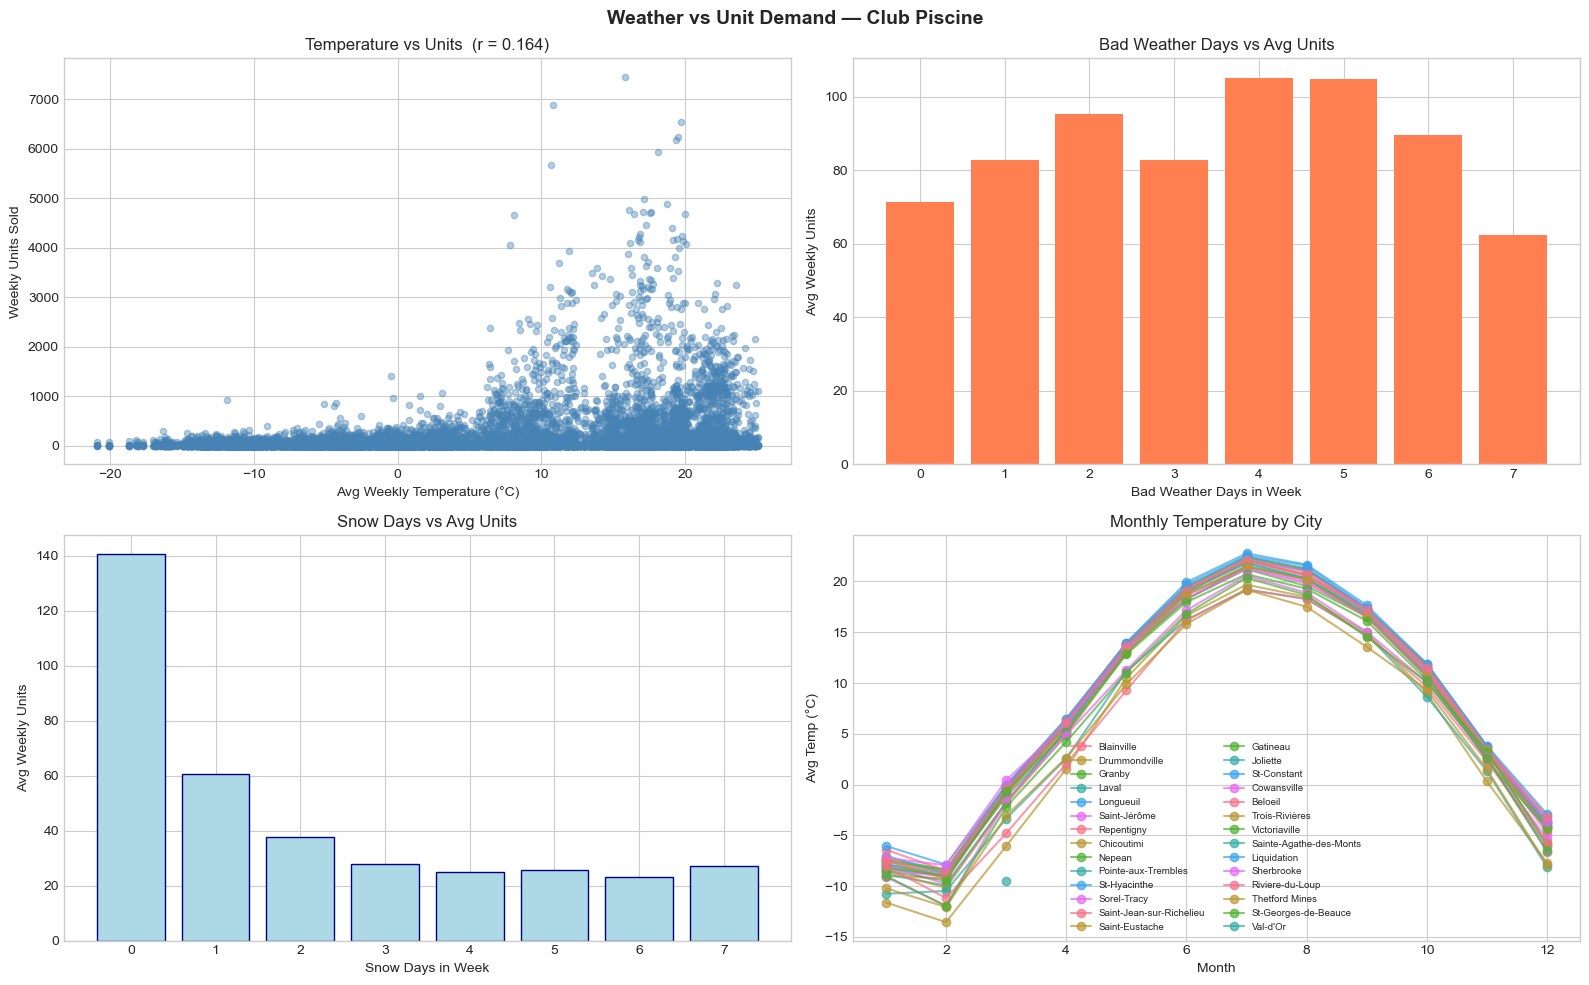

✅ Saved: weather_vs_units.png


In [27]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

ax1 = axes[0, 0]
ax1.scatter(weekly_weather['avg_temp'], weekly_weather['units'], alpha=0.4, color='steelblue', s=20)
corr = weekly_weather['avg_temp'].corr(weekly_weather['units'])
ax1.set_xlabel('Avg Weekly Temperature (°C)')
ax1.set_ylabel('Weekly Units Sold')
ax1.set_title(f'Temperature vs Units  (r = {corr:.3f})')

ax2 = axes[0, 1]
bw = weekly_weather.groupby('bad_weather_days')['units'].mean()
ax2.bar(bw.index, bw.values, color='coral')
ax2.set_xlabel('Bad Weather Days in Week')
ax2.set_ylabel('Avg Weekly Units')
ax2.set_title('Bad Weather Days vs Avg Units')

ax3 = axes[1, 0]
sn = weekly_weather.groupby('snow_days')['units'].mean()
ax3.bar(sn.index, sn.values, color='lightblue', edgecolor='navy')
ax3.set_xlabel('Snow Days in Week')
ax3.set_ylabel('Avg Weekly Units')
ax3.set_title('Snow Days vs Avg Units')

ax4 = axes[1, 1]
for city in weekly_weather['city'].dropna().unique():
    d = weekly_weather[weekly_weather['city']==city].groupby('month')['avg_temp'].mean()
    ax4.plot(d.index, d.values, marker='o', label=city, alpha=0.7)
ax4.set_xlabel('Month')
ax4.set_ylabel('Avg Temp (°C)')
ax4.set_title('Monthly Temperature by City')
ax4.legend(fontsize=7, ncol=2)

plt.suptitle('Weather vs Unit Demand — Club Piscine', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES / 'weather_vs_units.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: weather_vs_units.png')


---
## Cell 10: Save Outputs
---

In [28]:
weather_weekly.to_csv(DATA_PROCESSED / 'weather_by_city_week.csv', index=False)
weekly_weather.to_csv(DATA_PROCESSED / 'weekly_units_weather.csv', index=False)
print(f'✅ Saved: weather_by_city_week.csv  ({weather_weekly.shape})')
print(f'✅ Saved: weekly_units_weather.csv  ({weekly_weather.shape})')
print('Next → 03_feature_engineering.ipynb')

✅ Saved: weather_by_city_week.csv  ((3429, 11))
✅ Saved: weekly_units_weather.csv  ((24323, 20))
Next → 03_feature_engineering.ipynb
